
# Módulo 5: Data storytelling y buenas prácticas en visualización de datos

En el último módulo del curso nos centraremos en **cómo contar historias con datos** y en las mejores prácticas para crear visualizaciones claras, informativas y estéticamente agradables. Una visualización efectiva no es sólo bonita: debe transmitir el mensaje de forma directa, evitar distorsiones y guiar a la audiencia a través de una narrativa. A lo largo de este cuaderno aprenderás a seleccionar el gráfico adecuado, reducir el ruido visual (o *chart junk*), aplicar paletas de colores apropiadas y diseñar figuras accesibles para todos los públicos.

Los principios de este módulo se inspiran en recomendaciones de expertos. Por ejemplo, el concepto de **data‑ink ratio** propuesto por Edward Tufte sugiere que el ratio entre la tinta utilizada para representar datos y la tinta total del gráfico debe ser lo más alto posible【193556389997209†L269-L272】. Asimismo, las pautas de la Universidad de Missouri recomiendan evitar gráficas de pastel para comparar categorías y optar por barras, columnas o tablas【307471894208167†L63-L90】.



## 1. Selecciona el gráfico adecuado

Elegir la representación gráfica correcta depende del tipo de pregunta y de los datos. Algunas reglas generales:

- **Comparar valores o categorías:** utiliza gráficos de barras o columnas y evita los diagramas de pastel para comparar categorías【307471894208167†L63-L90】. Los gráficos de barras permiten comparar longitudes de forma más precisa y acomodan muchos grupos sin saturar la vista.
- **Mostrar proporciones o partes de un total:** las gráficas de pastel o `donut` pueden funcionar cuando las categorías son muy pocas, pero frecuentemente se recomiendan alternativas como barras apiladas, treemaps o *waffle charts* porque mejoran la comparación【193556389997209†L335-L340】.
- **Representar distribuciones:** emplea histogramas, diagramas de densidad, cajas y bigotes (box plots) o violin plots para visualizar la dispersión y los outliers【193556389997209†L342-L348】.
- **Mostrar relaciones entre variables:** utiliza gráficos de dispersión; puedes variar el tamaño o color de los puntos para añadir dimensiones adicionales【193556389997209†L350-L355】.
- **Partes de una secuencia temporal:** líneas para datos continuos en el tiempo y barras para periodos discretos. Evita pies de página para series temporales【307471894208167†L68-L71】.

### Tabla de referencia rápida

La siguiente tabla resume algunas situaciones comunes y el tipo de gráfico recomendado. Recuerda que las tablas sólo deben contener frases cortas o palabras clave.

| Objetivo | Gráfico recomendado | Evitar |
| --- | --- | --- |
| Comparar categorías | Barras horizontales/verticales | Pie, donut |
| Proporciones con pocas categorías | Pie (solo con 3–4 categorías) | 3D pie, demasiadas categorías |
| Proporciones con muchas categorías | Treemap, barras apiladas | Pie, donut |
| Distribución numérica | Histograma, box plot | Barras para números |
| Relación entre dos variables | Dispersión, línea | Barras |
| Serie temporal continua | Línea | Pie, donut |



### Ejemplo: gráfico de pastel vs. gráfico de barras

A menudo se utilizan gráficos de pastel para mostrar la distribución de un conjunto de categorías. Sin embargo, como señala la literatura, las gráficas de pastel han caído en desgracia debido a la dificultad de hacer comparaciones precisas【193556389997209†L335-L339】. Veamos un ejemplo donde comparamos la cuota de mercado de cuatro productos utilizando un gráfico de pastel y un gráfico de barras.


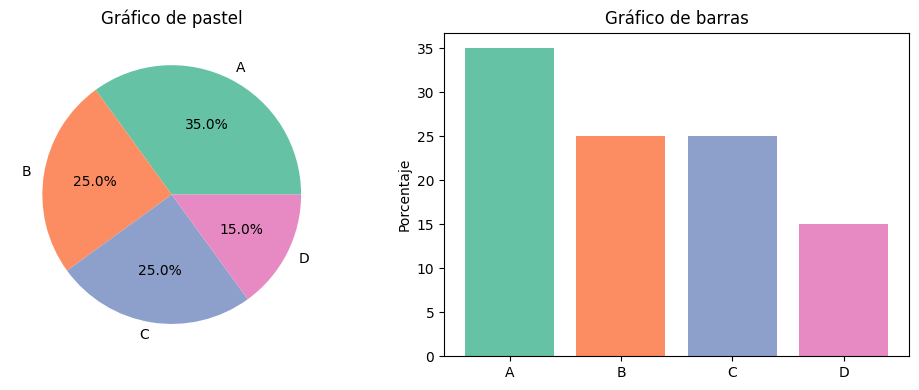

In [1]:

# Demostración de gráfico de pastel vs. gráfico de barras
import matplotlib.pyplot as plt
import numpy as np

# Datos de ejemplo
categorias = ['A', 'B', 'C', 'D']
valores = [35, 25, 25, 15]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Gráfico de pastel
axs[0].pie(valores, labels=categorias, autopct='%1.1f%%', colors=plt.cm.Set2.colors)
axs[0].set_title('Gráfico de pastel')

# Gráfico de barras
axs[1].bar(categorias, valores, color=plt.cm.Set2.colors)
axs[1].set_title('Gráfico de barras')
axs[1].set_ylabel('Porcentaje')

plt.tight_layout()
plt.show()



En el gráfico de pastel, es difícil distinguir la diferencia entre las porciones de 25 % y 35 %. En cambio, el gráfico de barras permite comparar rápidamente las alturas y ordenar las categorías de mayor a menor. Las barras también son mejores para visualizar cambios entre periodos y acomodar muchas categorías sin perder legibilidad.



## 2. Data‑ink ratio y eliminación del ruido visual

Edward Tufte acuñó los términos **data‑ink** y **chart junk** para referirse a la proporción de tinta dedicada a los datos en comparación con la tinta total del gráfico. Cuanto mayor sea la relación de *data‑ink*, más claro y conciso será el mensaje【193556389997209†L269-L272】. No‑data‑ink —líneas de cuadrícula excesivas, bordes decorativos, rellenos y efectos 3D— es considerado *chart junk* y debe eliminarse【131582722577104†L51-L61】.

### Recomendaciones para maximizar la data‑ink ratio

- Elimina marcos y líneas de cuadrícula innecesarios.
- Utiliza una tipografía legible y evita decoraciones excesivas como 3D o sombras.
- Reduce el número de colores a los necesarios para diferenciar categorías.
- Añade anotaciones solo cuando aporten información relevante.

### Ejemplo: gráfico sobrecargado vs. gráfico limpio

A continuación, comparamos un gráfico de barras con exceso de elementos decorativos y su versión simplificada.


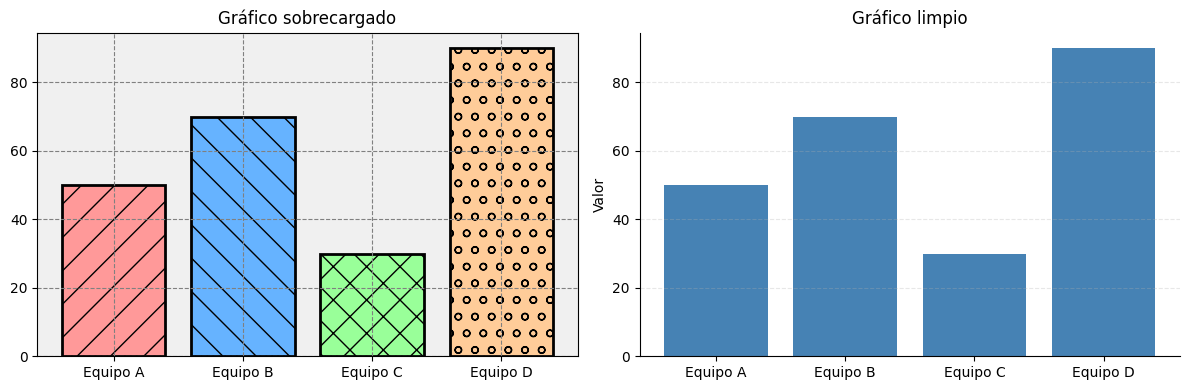

In [2]:
# Comparación de gráfico sobrecargado vs limpio
import matplotlib.pyplot as plt
import numpy as np

# Datos de ejemplo
equipos = ['Equipo A', 'Equipo B', 'Equipo C', 'Equipo D']
valores = [50, 70, 30, 90]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico sobrecargado
ax1.bar(equipos, valores, color=['#ff9999','#66b3ff','#99ff99','#ffcc99'],
        edgecolor='black', linewidth=2)
ax1.set_title('Gráfico sobrecargado')
ax1.grid(True, linestyle='--', color='gray')
ax1.set_facecolor('#f0f0f0')
# Añadir patrones con hatch
for bar, hatch in zip(ax1.patches, ['/', '\\', 'x', 'o']):
    bar.set_hatch(hatch)

# Gráfico limpio
ax2.bar(equipos, valores, color='steelblue')
ax2.set_title('Gráfico limpio')
ax2.set_ylabel('Valor')
# Ocultar el borde superior y derecho
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
# Líneas de cuadrícula ligeras
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()



En el primer gráfico se usan colores vibrantes, patrones de relleno, un fondo gris y cuadrícula gruesa. Todos estos elementos no aportan información adicional y distraen al lector. El segundo gráfico maximiza la *data‑ink ratio*: utiliza un único color, elimina bordes innecesarios y mantiene una cuadrícula sutil para ayudar a leer los valores.



## 3. Teoría del color y accesibilidad

El color es una poderosa herramienta para codificar información y llamar la atención del lector. Sin embargo, debe usarse con intención. Existen tres tipos principales de paletas de colores【193556389997209†L390-L400】:

- **Secuenciales:** van de claro a oscuro en uno o dos tonos relacionados y se utilizan para representar valores crecientes (p. ej., histogramas o mapas de calor). 
- **Divergentes:** combinan dos paletas secuenciales con un color neutro en el centro, ideales para mostrar desviaciones respecto a un valor medio (p. ej., mapas de correlación o diferencias respecto a un objetivo).
- **Cualitativas:** formadas por colores no relacionados que permiten distinguir categorías sin una relación de orden (p. ej., especies o grupos).

Las guías recomiendan diseñar figuras que funcionen tanto en color como en blanco y negro, utilizar paletas adaptadas a personas con daltonismo y combinar colores con símbolos y estilos de línea【193556389997209†L404-L417】.

### Ejemplo: uso de paletas secuencial, divergente y cualitativa


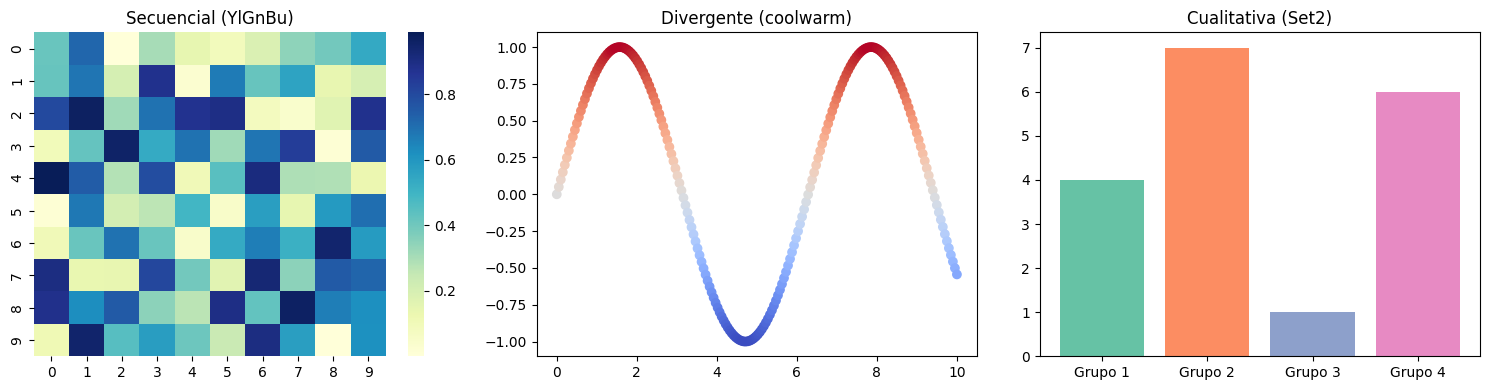

In [3]:

# Demostración de paletas de colores
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Generar datos para heatmap (secuencial)
np.random.seed(1)
matriz = np.random.rand(10, 10)

# Datos para scatter (divergente)
x = np.linspace(0, 10, 200)
y = np.sin(x)

# Datos para bar chart (cualitativa)
categorias = ['Grupo 1', 'Grupo 2', 'Grupo 3', 'Grupo 4']
valores = [4, 7, 1, 6]

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# Paleta secuencial
sns.heatmap(matriz, ax=axs[0], cmap='YlGnBu')
axs[0].set_title('Secuencial (YlGnBu)')

# Paleta divergente
scatter = axs[1].scatter(x, y, c=y, cmap='coolwarm')
axs[1].set_title('Divergente (coolwarm)')

# Paleta cualitativa
axs[2].bar(categorias, valores, color=sns.color_palette('Set2'))
axs[2].set_title('Cualitativa (Set2)')

plt.tight_layout()
plt.show()



En el ejemplo anterior:

- El mapa de calor utiliza una paleta secuencial `YlGnBu` para reflejar valores de baja a alta intensidad.
- El gráfico de dispersión emplea la paleta divergente `coolwarm` para resaltar valores positivos en rojo y negativos en azul.
- El gráfico de barras usa la paleta cualitativa `Set2` para diferenciar cuatro grupos sin implicar orden.

Para mejorar la accesibilidad, considera usar paletas diseñadas específicamente para personas con daltonismo (por ejemplo, `sns.color_palette('colorblind')`) y verifica que tus visualizaciones mantengan su legibilidad en escala de grises【193556389997209†L404-L417】.



## 4. Storytelling con datos y narrativa visual

Una buena visualización no solo muestra datos: cuenta una historia. Algunos principios para crear narrativas eficaces:

- **Define el mensaje antes de diseñar.** Identifica cuál es la idea principal y qué evidencias la respaldan.
- **Utiliza pequeños múltiplos (small multiples) o paneles** para comparar grupos o periodos de manera clara. Repetir la misma estructura de gráfico facilita identificar diferencias【193556389997209†L472-L480】.
- **Incluye incertidumbre** mediante barras de error o áreas sombreadas【193556389997209†L424-L439】. Mostrar solo medias puede ser engañoso; indica la variabilidad para evitar malas interpretaciones.
- **Anota los datos importantes** y usa títulos y subtítulos descriptivos. Las figuras deben ser entendibles por sí solas.
- **Evita mezclar modelos y datos sin explicaciones.** Si añades una línea de regresión, explica el modelo y su interpretación【193556389997209†L483-L495】.

### Ejemplo: Pequeños múltiplos con `seaborn`

Vamos a usar el conjunto de datos `tips` de Seaborn para comparar la distribución de las propinas por día de la semana utilizando *small multiples*.


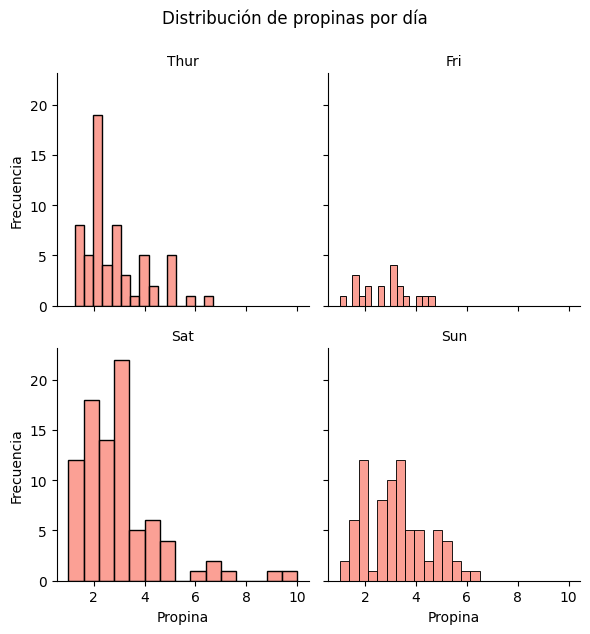

In [4]:

import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset('tips')

# Crear un grid de histogramas por día de la semana
g = sns.FacetGrid(tips, col='day', col_wrap=2, height=3)
g.map_dataframe(sns.histplot, x='tip', bins=15, color='salmon')
g.set_titles('{col_name}')
g.set_axis_labels('Propina', 'Frecuencia')
g.fig.suptitle('Distribución de propinas por día', y=1.05)
plt.show()



En este grid, cada panel representa un día distinto (`Thur`, `Fri`, `Sat` y `Sun`). Usar la misma escala y el mismo tipo de gráfico facilita comparar la forma y dispersión de las propinas según el día. Este tipo de diseño es conocido como **small multiples** y está recomendado para destacar diferencias en series temporales o grupos【193556389997209†L472-L480】.



### Ejemplo: Incluir incertidumbre con barras de error

Representar la incertidumbre ayuda a contextualizar tus datos y evitar interpretaciones erróneas. Aquí calcularemos la media y el intervalo de confianza para las cuentas (`total_bill`) por día y lo representaremos con barras de error.


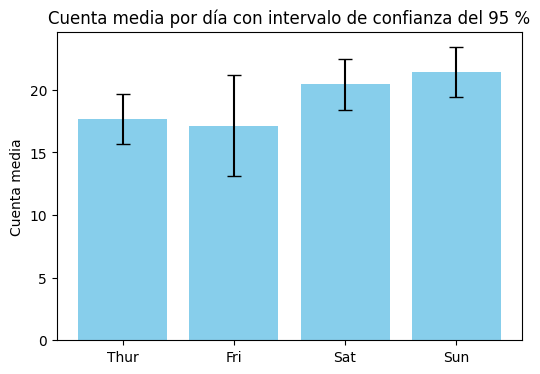

In [5]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Calcular medias y errores estándar por día
groups = tips.groupby('day')['total_bill']
media = groups.mean()
sem = groups.sem()

# Cálculo de intervalos de confianza al 95%
ci = sem * stats.t.ppf((1 + 0.95) / 2, df=groups.count() - 1)

# Crear gráfico de barras con barras de error
plt.figure(figsize=(6, 4))
plt.bar(media.index, media.values, yerr=ci.values, capsize=5, color='skyblue')
plt.ylabel('Cuenta media')
plt.title('Cuenta media por día con intervalo de confianza del 95 %')
plt.show()



Las barras de error muestran la variabilidad de los datos; es importante indicar en la leyenda o el título el tipo de intervalo utilizado (en este caso, intervalo de confianza del 95 %)【193556389997209†L424-L449】. Este enfoque ayuda a contar una historia más completa y evitar que la audiencia saque conclusiones equivocadas.



## 5. Conclusiones y ejercicios

En este módulo hemos visto cómo elegir el tipo de gráfico adecuado, reducir el ruido visual, aplicar colores de forma efectiva y construir una narrativa sólida.

**Ideas clave:**

- Mantén la *data‑ink ratio* alta eliminando elementos superfluos【193556389997209†L269-L272】.
- Selecciona gráficos en función de la pregunta: barras para comparaciones, histogramas para distribuciones, dispersión para relaciones, etc.【193556389997209†L342-L355】【307471894208167†L63-L90】.
- Evita las gráficas de pastel cuando la comparación de valores sea importante; usa barras, treemaps u otros formatos【193556389997209†L335-L340】.
- Usa paletas secuenciales, divergentes o cualitativas según el tipo de dato y verifica su accesibilidad【193556389997209†L390-L400】【193556389997209†L404-L417】.
- Utiliza *small multiples* y barras de error para mostrar comparaciones y la incertidumbre de forma transparente【193556389997209†L472-L480】【193556389997209†L424-L439】.

### Ejercicios propuestos

1. **Rediseña un gráfico**: busca un gráfico de tu interés que creas que está mal diseñado (por ejemplo, un gráfico de pastel con muchas categorías o una visualización sobrecargada). Reprodúcelo y luego rediseñalo aplicando las mejores prácticas aprendidas.
2. **Explora paletas accesibles**: crea una visualización que utilice la paleta `colorblind` de Seaborn y verifica cómo se ve en escala de grises utilizando el método `sns.color_palette('gray')`. Reflexiona sobre la diferencia.
3. **Cuenta una historia con *small multiples***: utiliza un conjunto de datos (por ejemplo, un dataset económico o deportivo) y crea una serie de paneles que comparen la evolución de diferentes grupos a lo largo del tiempo. Añade títulos y comentarios que guíen la lectura del público.

Con esto concluye el módulo 5 y el curso. ¡Felicidades por llegar hasta aquí! La próxima vez que diseñes un gráfico, recuerda que cada elemento debe estar al servicio de la historia que quieres contar.
